# Time-Series Calibration of Quantile Forecasts

The preceding notebook extended one-day-ahead water-demand forecasting from point
prediction to **conditional quantile prediction**.

Linear quantile regression (QR) proved competitive with quantile XGBoost and produced
quantiles whose empirical frequencies were closer to their nominal probability levels.
But its raw 10th-to-90th percentile band still covered only about **74%** of the
rolling-validation observations rather than the nominal 80%.

That leaves a natural next question:

> **Can we calibrate the QR uncertainty band for sequential forecasting without making
> the intervals unnecessarily wide?**

This notebook investigates a small progression of time-series calibration methods:

1. **Raw Linear QR** — no calibration;
2. **Trailing CQR** — recalibration from recent conformity scores;
3. **Two-sided Adaptive Conformal Inference (ACI)**;
4. **Two-sided Conformal PID**;
5. **Asymmetric Conformal PID**.

The objective is not to reward complexity. Each additional method is retained only if
it improves the trade-off among:

- empirical coverage;
- interval width;
- local stability through time;
- lower/upper-tail balance;
- and implementation complexity.

## References

**Adaptive Conformal Inference**

Gibbs, I. & Candès, E. (2021). *Adaptive Conformal Inference Under Distribution Shift*.
NeurIPS 34.

https://proceedings.neurips.cc/paper/2021/hash/0d441de75945e5acbc865406fc9a2559-Abstract.html

**Conformal PID**

Angelopoulos, A. N., Candès, E. J., & Tibshirani, R. J. (2023).
*Conformal PID Control for Time Series Prediction*. NeurIPS 36.

https://proceedings.neurips.cc/paper_files/paper/2023/hash/47f2fad8c1111d07f83c91be7870f8db-Abstract-Conference.html

## Evaluation boundary

The calibration workflow remains chronological:

- **2021:** initial out-of-sample conformity-score history;
- **2022:** calibration-parameter and memory-length selection;
- **2023-01-01 through 2025-03-31:** reported method comparison;
- the previously opened April 2025--March 2026 holdout is not reused.

Every interval is constructed **before** the corresponding outcome is observed. Today's
outcome can update the calibration state only for tomorrow's forecast.

## 1. Setup

The base forecasting model is unchanged from Notebook 03:

- Matrix B predictors;
- unregularized Linear QR;
- quantiles \(.10,.50,.90\);
- foldwise standardization;
- quarterly expanding-window refits.

Reconstructing the forecasts here keeps this notebook independently executable while
preserving exactly the same one-day-ahead information boundary.

In [1]:
from pathlib import Path
import os
import subprocess
import sys
from time import perf_counter
import platform
import importlib.metadata as metadata

REPOSITORY_NAME = "municipal-water-demand-forecasting"
REPOSITORY_URL = (
    "https://github.com/fureyc/"
    "municipal-water-demand-forecasting.git"
)


def find_repository_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "config" / "modeling.yml").exists()
            and (
                candidate
                / "data"
                / "processed"
                / "fort_collins_daily_water_weather.csv"
            ).exists()
        ):
            return candidate

    return None


repo_root = find_repository_root()

if repo_root is None:
    clone_parent = Path("/content") if Path("/content").exists() else Path.cwd()
    clone_target = clone_parent / REPOSITORY_NAME

    if not clone_target.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPOSITORY_URL,
                str(clone_target),
            ],
            check=True,
        )

    repo_root = find_repository_root(clone_target)

if repo_root is None:
    raise FileNotFoundError("Could not locate the project repository.")

os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

Repository root: /content/municipal-water-demand-forecasting


In [2]:
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(repo_root / "requirements.txt"),
    ],
    check=True,
)

print("Dependencies are available.")

Dependencies are available.


In [3]:
from __future__ import annotations

from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.linear_model import QuantileRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.features.build_forecasting_features import (
    load_and_build_forecasting_features,
)

FEATURE_MATRIX = "B"

LOWER_TAU = 0.10
MEDIAN_TAU = 0.50
UPPER_TAU = 0.90
QUANTILES = (LOWER_TAU, MEDIAN_TAU, UPPER_TAU)

TARGET_COVERAGE = 0.80
TARGET_MISCOVERAGE = 0.20
TAIL_MISCOVERAGE = 0.10

BURNIN_START = pd.Timestamp("2021-01-01")
BURNIN_END = pd.Timestamp("2021-12-31")
TUNING_START = pd.Timestamp("2022-01-01")
TUNING_END = pd.Timestamp("2022-12-31")
EVALUATION_START = pd.Timestamp("2023-01-01")
EVALUATION_END = pd.Timestamp("2025-03-31")

WINDOWS = (90, 180, 365)
LOCAL_COVERAGE_WINDOW = 90

ACI_GAMMAS = (0.001, 0.0025, 0.005, 0.01, 0.02)
PID_CSAT_GRID = (0.5, 1.0, 2.0)
PID_KI_MULTIPLIERS = (0.25, 0.5, 1.0)

versions = pd.Series(
    {
        "Python": platform.python_version(),
        "NumPy": metadata.version("numpy"),
        "pandas": metadata.version("pandas"),
        "Matplotlib": metadata.version("matplotlib"),
        "scikit-learn": metadata.version("scikit-learn"),
    },
    name="version",
)

display(versions.to_frame())

,version
Python,3.12.13
NumPy,2.0.2
pandas,2.2.3
Matplotlib,3.10.0
scikit-learn,1.6.1


In [4]:
DATA_PATH = (
    repo_root
    / "data"
    / "processed"
    / "fort_collins_daily_water_weather.csv"
)

feature_set = load_and_build_forecasting_features(DATA_PATH)

dates = pd.to_datetime(feature_set.dates).reset_index(drop=True)
y = feature_set.target.to_numpy(dtype=float)

if FEATURE_MATRIX.upper() == "A":
    X_df = feature_set.matrix_a.copy()
elif FEATURE_MATRIX.upper() == "B":
    X_df = feature_set.matrix_b.copy()
else:
    raise ValueError("FEATURE_MATRIX must be 'A' or 'B'.")

X = X_df.to_numpy(dtype=float)

assert len(dates) == len(y) == len(X_df)
assert dates.is_monotonic_increasing
assert dates.is_unique
assert np.isfinite(X).all()
assert np.isfinite(y).all()

print("Feature matrix:", FEATURE_MATRIX)
print("Observations:", len(y))
print("Predictors:", X.shape[1])
print("Range:", dates.min().date(), "through", dates.max().date())

Feature matrix: B
Observations: 2254
Predictors: 54
Range: 2020-01-29 through 2026-03-31


In [5]:
def make_linear_quantile_model(tau):
    return Pipeline(
        [
            ("scale", StandardScaler()),
            (
                "quantile",
                QuantileRegressor(
                    quantile=tau,
                    alpha=0.0,
                    solver="highs",
                    fit_intercept=True,
                ),
            ),
        ]
    )


def quarter_boundaries(start, end):
    starts = pd.date_range(
        pd.Timestamp(start).to_period("Q").start_time,
        pd.Timestamp(end).to_period("Q").start_time,
        freq="QS",
    )

    out = []

    for q_start in starts:
        q_end = pd.Timestamp(
            q_start.to_period("Q").end_time.date()
        )

        out.append(
            (
                max(q_start, pd.Timestamp(start)),
                min(q_end, pd.Timestamp(end)),
            )
        )

    return out


def build_quarterly_oof_quantile_forecasts(
    X,
    y,
    dates,
    forecast_start,
    forecast_end,
):
    rows = []
    fit_rows = []

    for q_start, q_end in quarter_boundaries(
        forecast_start,
        forecast_end,
    ):
        train_idx = np.flatnonzero(
            (dates < q_start).to_numpy()
        )

        test_idx = np.flatnonzero(
            dates.between(
                q_start,
                q_end,
                inclusive="both",
            ).to_numpy()
        )

        if len(test_idx) == 0:
            continue

        assert dates.iloc[train_idx].max() < dates.iloc[test_idx].min()

        predictions = {}

        for tau in QUANTILES:
            model = make_linear_quantile_model(tau)

            start = perf_counter()
            model.fit(
                X[train_idx],
                y[train_idx],
            )
            fit_seconds = perf_counter() - start

            predictions[tau] = np.asarray(
                model.predict(X[test_idx]),
                dtype=float,
            ).ravel()

            fit_rows.append(
                {
                    "forecast_start": q_start,
                    "forecast_end": q_end,
                    "tau": tau,
                    "n_train": len(train_idx),
                    "n_forecast": len(test_idx),
                    "fit_seconds": fit_seconds,
                }
            )

        if EVALUATION_START <= q_start <= EVALUATION_END:
            fold = (
                (q_start.year - EVALUATION_START.year) * 4
                + q_start.quarter
            )
        else:
            fold = np.nan

        for j, idx in enumerate(test_idx):
            rows.append(
                {
                    "date": dates.iloc[idx],
                    "y_true": float(y[idx]),
                    "q10": float(predictions[LOWER_TAU][j]),
                    "q50": float(predictions[MEDIAN_TAU][j]),
                    "q90": float(predictions[UPPER_TAU][j]),
                    "evaluation_fold": fold,
                }
            )

    predictions = (
        pd.DataFrame(rows)
        .sort_values("date")
        .reset_index(drop=True)
    )

    return predictions, pd.DataFrame(fit_rows)


oof_predictions, qr_fit_times = build_quarterly_oof_quantile_forecasts(
    X=X,
    y=y,
    dates=dates,
    forecast_start=BURNIN_START,
    forecast_end=EVALUATION_END,
)

print("OOF rows:", len(oof_predictions))
print(
    "OOF range:",
    oof_predictions["date"].min().date(),
    "through",
    oof_predictions["date"].max().date(),
)

OOF rows: 1551
OOF range: 2021-01-01 through 2025-03-31


In [6]:
def add_raw_scores(frame):
    out = frame.copy()

    out["score_two_sided"] = np.maximum(
        out["q10"] - out["y_true"],
        out["y_true"] - out["q90"],
    )
    out["score_lower"] = (
        out["q10"] - out["y_true"]
    )
    out["score_upper"] = (
        out["y_true"] - out["q90"]
    )

    return out


oof = add_raw_scores(oof_predictions)

burnin = oof.loc[
    oof["date"].between(
        BURNIN_START,
        BURNIN_END,
        inclusive="both",
    )
].copy()

tuning = oof.loc[
    oof["date"].between(
        TUNING_START,
        TUNING_END,
        inclusive="both",
    )
].copy()

evaluation = oof.loc[
    oof["date"].between(
        EVALUATION_START,
        EVALUATION_END,
        inclusive="both",
    )
].copy()

assert burnin["date"].max() < tuning["date"].min()
assert tuning["date"].max() < evaluation["date"].min()

print("Burn-in:", len(burnin))
print("2022 tuning:", len(tuning))
print("2023-2025 evaluation:", len(evaluation))

Burn-in: 365
2022 tuning: 365
2023-2025 evaluation: 821


## 2. From raw quantiles to sequential calibration

For the raw QR band

$$
[L_t,U_t]
=
[\widehat q_{.10,t},\widehat q_{.90,t}],
$$

a standard two-sided CQR conformity score is

$$
s_t
=
\max\{L_t-y_t,\ y_t-U_t\}.
$$

A recent empirical quantile of these scores can expand or contract the raw QR band.

### Trailing CQR

Trailing CQR uses a fixed rolling history of recent conformity scores but no explicit
feedback controller.

### Adaptive Conformal Inference

ACI adapts the effective miscoverage level online:

$$
\alpha_{t+1}
=
\alpha_t+\gamma(\alpha-\mathrm{err}_t),
$$

where $\mathrm{err}_t=1$ if today's calibrated interval misses.

### Conformal PID

The PID construction supplements a recent score quantile with an integral correction based
on accumulated coverage error. We use the lightweight tangent integrator introduced in the
Conformal PID paper.

### Asymmetric PID

The asymmetric version keeps separate lower- and upper-tail scores,

$$
s_t^L=L_t-y_t,
\qquad
s_t^U=y_t-U_t,
$$

and calibrates the two endpoints independently.

This is more flexible, but it also maintains twice the score history and two controller states.
Whether that additional flexibility helps is an empirical question.

In [7]:
def empirical_higher_quantile(values, p):
    values = np.asarray(values, dtype=float)

    if p <= 0:
        return -np.inf
    if p >= 1:
        return np.inf

    return float(
        np.quantile(
            values,
            p,
            method="higher",
        )
    )


def tan_integrator(
    cumulative_error,
    t,
    c_sat,
    k_i,
):
    if t <= 0 or k_i == 0:
        return 0.0

    argument = (
        cumulative_error
        * np.log(t + 1.0)
        / (c_sat * (t + 1.0))
    )

    if argument >= np.pi / 2:
        return np.inf
    if argument <= -np.pi / 2:
        return -np.inf

    return float(
        k_i * np.tan(argument)
    )


def interval_diagnostics(frame):
    y_true = frame["y_true"].to_numpy(dtype=float)
    lower = frame["lower"].to_numpy(dtype=float)
    upper = frame["upper"].to_numpy(dtype=float)

    covered = (
        (y_true >= lower)
        & (y_true <= upper)
    )

    widths = upper - lower

    return {
        "coverage_80": float(covered.mean()),
        "average_width": float(widths.mean()),
        "median_width": float(np.median(widths)),
        "lower_miss_rate": float(np.mean(y_true < lower)),
        "upper_miss_rate": float(np.mean(y_true > upper)),
        "crossing_rate": float(np.mean(lower > upper)),
    }


def local_coverage_diagnostics(
    frame,
    window=LOCAL_COVERAGE_WINDOW,
):
    covered = (
        (frame["y_true"] >= frame["lower"])
        & (frame["y_true"] <= frame["upper"])
    ).astype(float)

    rolling = (
        covered
        .rolling(
            window,
            min_periods=window,
        )
        .mean()
        .dropna()
    )

    if len(rolling) == 0:
        return {
            "rolling_coverage_mae": np.nan,
            "rolling_coverage_min": np.nan,
            "rolling_coverage_max": np.nan,
            "rolling_coverage_sd": np.nan,
        }

    return {
        "rolling_coverage_mae": float(
            np.mean(
                np.abs(
                    rolling - TARGET_COVERAGE
                )
            )
        ),
        "rolling_coverage_min": float(rolling.min()),
        "rolling_coverage_max": float(rolling.max()),
        "rolling_coverage_sd": float(rolling.std(ddof=0)),
    }


def tuning_loss(frame):
    pooled = interval_diagnostics(frame)
    local = local_coverage_diagnostics(frame)

    pooled_loss = (
        abs(
            pooled["coverage_80"] - TARGET_COVERAGE
        )
        + 0.5
        * (
            abs(
                pooled["lower_miss_rate"] - TAIL_MISCOVERAGE
            )
            + abs(
                pooled["upper_miss_rate"] - TAIL_MISCOVERAGE
            )
        )
    )

    return {
        **pooled,
        **local,
        "pooled_calibration_loss": pooled_loss,
        "selection_loss": (
            pooled_loss
            + local["rolling_coverage_mae"]
        ),
    }

In [8]:
def run_raw_qr(frame):
    out = frame[
        [
            "date",
            "y_true",
            "q10",
            "q50",
            "q90",
            "evaluation_fold",
        ]
    ].copy()

    out["lower"] = out["q10"]
    out["upper"] = out["q90"]
    out["method"] = "Raw Linear QR"

    return out


def run_trailing_cqr(
    frame,
    burnin_scores,
    window,
):
    history = deque(
        np.asarray(
            burnin_scores,
            dtype=float,
        )[-window:],
        maxlen=window,
    )

    rows = []

    for row in frame.itertuples(index=False):
        q = empirical_higher_quantile(
            history,
            1.0 - TARGET_MISCOVERAGE,
        )

        lower = row.q10 - q
        upper = row.q90 + q

        rows.append(
            {
                "date": row.date,
                "y_true": row.y_true,
                "q10": row.q10,
                "q50": row.q50,
                "q90": row.q90,
                "evaluation_fold": row.evaluation_fold,
                "lower": lower,
                "upper": upper,
                "method": "Trailing CQR",
            }
        )

        history.append(row.score_two_sided)

    return pd.DataFrame(rows)


def run_aci(
    frame,
    burnin_scores,
    window,
    gamma,
):
    history = deque(
        np.asarray(
            burnin_scores,
            dtype=float,
        )[-window:],
        maxlen=window,
    )

    alpha_t = TARGET_MISCOVERAGE
    rows = []

    for row in frame.itertuples(index=False):
        if alpha_t <= 1.0 / (len(history) + 1.0):
            q = np.inf
        else:
            q = empirical_higher_quantile(
                history,
                1.0
                - np.clip(
                    alpha_t,
                    0.0,
                    1.0,
                ),
            )

        lower = row.q10 - q
        upper = row.q90 + q

        covered = (
            (row.y_true >= lower)
            and (row.y_true <= upper)
        )
        err = 0.0 if covered else 1.0

        rows.append(
            {
                "date": row.date,
                "y_true": row.y_true,
                "q10": row.q10,
                "q50": row.q50,
                "q90": row.q90,
                "evaluation_fold": row.evaluation_fold,
                "lower": lower,
                "upper": upper,
                "alpha_t": alpha_t,
                "method": "Two-sided ACI",
            }
        )

        history.append(row.score_two_sided)
        alpha_t = (
            alpha_t
            + gamma
            * (
                TARGET_MISCOVERAGE
                - err
            )
        )

    return pd.DataFrame(rows)


def run_pid_two_sided(
    frame,
    burnin_scores,
    window,
    c_sat,
    k_i,
):
    history = deque(
        np.asarray(
            burnin_scores,
            dtype=float,
        )[-window:],
        maxlen=window,
    )

    cumulative_error = 0.0
    t_online = 0
    rows = []

    for row in frame.itertuples(index=False):
        scorecast = empirical_higher_quantile(
            history,
            1.0 - TARGET_MISCOVERAGE,
        )

        integral = tan_integrator(
            cumulative_error,
            t_online,
            c_sat,
            k_i,
        )

        q = scorecast + integral
        lower = row.q10 - q
        upper = row.q90 + q

        covered = (
            (row.y_true >= lower)
            and (row.y_true <= upper)
        )
        err = 0.0 if covered else 1.0

        rows.append(
            {
                "date": row.date,
                "y_true": row.y_true,
                "q10": row.q10,
                "q50": row.q50,
                "q90": row.q90,
                "evaluation_fold": row.evaluation_fold,
                "lower": lower,
                "upper": upper,
                "method": "Two-sided PID",
            }
        )

        history.append(row.score_two_sided)
        cumulative_error += (
            err - TARGET_MISCOVERAGE
        )
        t_online += 1

    return pd.DataFrame(rows)


def run_pid_asymmetric(
    frame,
    burnin_lower_scores,
    burnin_upper_scores,
    window,
    c_sat,
    k_i_lower,
    k_i_upper,
):
    lower_history = deque(
        np.asarray(
            burnin_lower_scores,
            dtype=float,
        )[-window:],
        maxlen=window,
    )

    upper_history = deque(
        np.asarray(
            burnin_upper_scores,
            dtype=float,
        )[-window:],
        maxlen=window,
    )

    cumulative_lower = 0.0
    cumulative_upper = 0.0
    t_online = 0
    rows = []

    for row in frame.itertuples(index=False):
        lower_scorecast = empirical_higher_quantile(
            lower_history,
            1.0 - TAIL_MISCOVERAGE,
        )

        upper_scorecast = empirical_higher_quantile(
            upper_history,
            1.0 - TAIL_MISCOVERAGE,
        )

        lower_integral = tan_integrator(
            cumulative_lower,
            t_online,
            c_sat,
            k_i_lower,
        )

        upper_integral = tan_integrator(
            cumulative_upper,
            t_online,
            c_sat,
            k_i_upper,
        )

        lower = (
            row.q10
            - lower_scorecast
            - lower_integral
        )
        upper = (
            row.q90
            + upper_scorecast
            + upper_integral
        )

        lower_err = float(
            row.y_true < lower
        )
        upper_err = float(
            row.y_true > upper
        )

        rows.append(
            {
                "date": row.date,
                "y_true": row.y_true,
                "q10": row.q10,
                "q50": row.q50,
                "q90": row.q90,
                "evaluation_fold": row.evaluation_fold,
                "lower": lower,
                "upper": upper,
                "method": "Asymmetric PID",
            }
        )

        lower_history.append(
            row.score_lower
        )
        upper_history.append(
            row.score_upper
        )

        cumulative_lower += (
            lower_err - TAIL_MISCOVERAGE
        )
        cumulative_upper += (
            upper_err - TAIL_MISCOVERAGE
        )
        t_online += 1

    return pd.DataFrame(rows)

## 3. Select calibration settings using 2022 only

The calibration methods contain choices that control how quickly they respond to changing
forecast errors.

We compare conformity-score histories of

\[
W\in\{90,180,365\}\text{ days},
\]

roughly corresponding to one quarter, half a year, and a full year.

For each candidate window:

- Trailing CQR has no additional controller parameter;
- ACI selects \(\gamma\) from a small prespecified grid;
- PID selects the integral-controller scale from a small prespecified grid.

The tuning score combines:

- pooled coverage error;
- imbalance between the lower and upper tail;
- 90-day local coverage error.

Average width is used only as a tie-breaker.

This entire selection step uses **2022 only**.

In [9]:
burn_two_all = burnin[
    "score_two_sided"
].to_numpy()

burn_low_all = burnin[
    "score_lower"
].to_numpy()

burn_up_all = burnin[
    "score_upper"
].to_numpy()

tuning_rows = []
selected_configs = {}

for window in WINDOWS:
    burn_two = burn_two_all[-window:]
    burn_low = burn_low_all[-window:]
    burn_up = burn_up_all[-window:]

    two_scale = float(
        np.max(np.abs(burn_two))
    )
    lower_scale = float(
        np.max(np.abs(burn_low))
    )
    upper_scale = float(
        np.max(np.abs(burn_up))
    )

    # Trailing CQR
    result = run_trailing_cqr(
        tuning,
        burn_two,
        window,
    )
    diag = tuning_loss(result)

    trailing_row = {
        "method": "Trailing CQR",
        "window": window,
        "gamma": np.nan,
        "c_sat": np.nan,
        "lower_ki_multiplier": np.nan,
        "upper_ki_multiplier": np.nan,
        **diag,
    }
    tuning_rows.append(trailing_row)
    selected_configs[
        ("Trailing CQR", window)
    ] = trailing_row

    # ACI
    candidates = []

    for gamma in ACI_GAMMAS:
        result = run_aci(
            tuning,
            burn_two,
            window,
            gamma,
        )
        diag = tuning_loss(result)

        row = {
            "method": "Two-sided ACI",
            "window": window,
            "gamma": gamma,
            "c_sat": np.nan,
            "lower_ki_multiplier": np.nan,
            "upper_ki_multiplier": np.nan,
            **diag,
        }

        tuning_rows.append(row)
        candidates.append(row)

    selected_configs[
        ("Two-sided ACI", window)
    ] = sorted(
        candidates,
        key=lambda r: (
            r["selection_loss"],
            r["average_width"],
        ),
    )[0]

    # Two-sided PID
    candidates = []

    for c_sat in PID_CSAT_GRID:
        for mult in PID_KI_MULTIPLIERS:
            k_i = mult * two_scale

            result = run_pid_two_sided(
                tuning,
                burn_two,
                window,
                c_sat,
                k_i,
            )
            diag = tuning_loss(result)

            row = {
                "method": "Two-sided PID",
                "window": window,
                "gamma": np.nan,
                "c_sat": c_sat,
                "lower_ki_multiplier": mult,
                "upper_ki_multiplier": mult,
                "k_i_lower": k_i,
                "k_i_upper": k_i,
                **diag,
            }

            tuning_rows.append(row)
            candidates.append(row)

    selected_configs[
        ("Two-sided PID", window)
    ] = sorted(
        candidates,
        key=lambda r: (
            r["selection_loss"],
            r["average_width"],
        ),
    )[0]

    # Asymmetric PID
    candidates = []

    for c_sat in PID_CSAT_GRID:
        for lower_mult in PID_KI_MULTIPLIERS:
            for upper_mult in PID_KI_MULTIPLIERS:
                k_i_lower = (
                    lower_mult * lower_scale
                )
                k_i_upper = (
                    upper_mult * upper_scale
                )

                result = run_pid_asymmetric(
                    tuning,
                    burn_low,
                    burn_up,
                    window,
                    c_sat,
                    k_i_lower,
                    k_i_upper,
                )
                diag = tuning_loss(result)

                row = {
                    "method": "Asymmetric PID",
                    "window": window,
                    "gamma": np.nan,
                    "c_sat": c_sat,
                    "lower_ki_multiplier": lower_mult,
                    "upper_ki_multiplier": upper_mult,
                    "k_i_lower": k_i_lower,
                    "k_i_upper": k_i_upper,
                    **diag,
                }

                tuning_rows.append(row)
                candidates.append(row)

    selected_configs[
        ("Asymmetric PID", window)
    ] = sorted(
        candidates,
        key=lambda r: (
            r["selection_loss"],
            r["average_width"],
        ),
    )[0]

tuning_results = pd.DataFrame(
    tuning_rows
)

print("Finished 2022 calibration search.")

Finished 2022 calibration search.


In [10]:
best_within_window_rows = []

for method in (
    "Trailing CQR",
    "Two-sided ACI",
    "Two-sided PID",
    "Asymmetric PID",
):
    for window in WINDOWS:
        best_within_window_rows.append(
            selected_configs[
                (method, window)
            ]
        )

best_within_window = (
    pd.DataFrame(
        best_within_window_rows
    )
    .sort_values(
        ["method", "window"]
    )
    .reset_index(drop=True)
)

display(
    best_within_window[
        [
            "method",
            "window",
            "coverage_80",
            "average_width",
            "lower_miss_rate",
            "upper_miss_rate",
            "rolling_coverage_mae",
            "selection_loss",
            "gamma",
            "c_sat",
            "lower_ki_multiplier",
            "upper_ki_multiplier",
        ]
    ].round(5)
)

,method,window,coverage_80,average_width,lower_miss_rate,upper_miss_rate,rolling_coverage_mae,selection_loss,gamma,c_sat,lower_ki_multiplier,upper_ki_multiplier
0,Asymmetric PID,90,0.80000,3.53618,0.09589,0.10411,0.02693,0.03104,NaN,1.0,0.25,1.0
1,Asymmetric PID,180,0.79726,3.41535,0.09863,0.10411,0.02194,0.02742,NaN,2.0,1.00,1.0
2,Asymmetric PID,365,0.79452,3.65104,0.10411,0.10411,0.01518,0.02477,NaN,0.5,1.00,1.0
3,Trailing CQR,90,0.78082,3.28102,0.12877,0.09041,0.02774,0.06609,NaN,NaN,NaN,NaN
4,Trailing CQR,180,0.75890,3.17469,0.13425,0.10685,0.04569,0.10734,NaN,NaN,NaN,NaN
5,Trailing CQR,365,0.79452,3.25557,0.11781,0.08767,0.03269,0.05324,NaN,NaN,NaN,NaN
6,Two-sided ACI,90,0.78630,3.40773,0.12329,0.09041,0.01981,0.04994,0.0200,NaN,NaN,NaN
7,Two-sided ACI,180,0.79178,3.43376,0.12055,0.08767,0.02186,0.04652,0.0200,NaN,NaN,NaN
8,Two-sided ACI,365,0.79726,3.24599,0.11781,0.08493,0.02979,0.04897,0.0025,NaN,NaN,NaN
9,Two-sided PID,90,0.78904,3.48579,0.11233,0.09863,0.01952,0.03733,NaN,0.5,1.00,1.0


In [11]:
selected_rows = []

for method, group in best_within_window.groupby(
    "method"
):
    selected_rows.append(
        group.sort_values(
            [
                "selection_loss",
                "average_width",
            ]
        ).iloc[0]
    )

selected_2022 = (
    pd.DataFrame(selected_rows)
    .sort_values("method")
    .reset_index(drop=True)
)

display(
    selected_2022[
        [
            "method",
            "window",
            "coverage_80",
            "average_width",
            "lower_miss_rate",
            "upper_miss_rate",
            "rolling_coverage_mae",
            "selection_loss",
            "gamma",
            "c_sat",
            "lower_ki_multiplier",
            "upper_ki_multiplier",
        ]
    ].round(5)
)

selected_window_by_method = dict(
    zip(
        selected_2022["method"],
        selected_2022["window"].astype(int),
    )
)

print(
    "2022-selected windows:",
    selected_window_by_method,
)

,method,window,coverage_80,average_width,lower_miss_rate,upper_miss_rate,rolling_coverage_mae,selection_loss,gamma,c_sat,lower_ki_multiplier,upper_ki_multiplier
0,Asymmetric PID,365,0.79452,3.65104,0.10411,0.10411,0.01518,0.02477,NaN,0.5,1.0,1.0
1,Trailing CQR,365,0.79452,3.25557,0.11781,0.08767,0.03269,0.05324,NaN,NaN,NaN,NaN
2,Two-sided ACI,180,0.79178,3.43376,0.12055,0.08767,0.02186,0.04652,0.02,NaN,NaN,NaN
3,Two-sided PID,365,0.79178,3.47035,0.11233,0.09589,0.01872,0.03516,NaN,0.5,1.0,1.0


2022-selected windows: {'Asymmetric PID': 365, 'Trailing CQR': 365, 'Two-sided ACI': 180, 'Two-sided PID': 365}


### Calibration settings selected before the evaluation period

The 2022 tuning results do not identify a single best conformity-score memory for
every calibration method.

Trailing CQR and both PID variants favor a full 365-day history under the
prespecified calibration criterion, while ACI selects an intermediate
**180-day history** with $\gamma=0.02$.

For ACI, this selection reflects a compromise rather than a large separation among
the candidate windows. The 90-day history has slightly lower local coverage error,
while the 365-day history produces pooled coverage slightly closer to 80%. The
180-day history balances those objectives and attains the lowest overall selection
loss.

The asymmetric PID result also illustrates an important feature of the tuning
criterion. Its 365-day configuration is relatively wide, but it is selected because
of particularly stable local coverage and well-balanced lower- and upper-tail errors.
Interval width is deliberately used only as a tie-breaker during this pre-evaluation
calibration step.

All subsequent comparisons use these settings without retuning on the 2023--2025
evaluation period.

## 4. Prospective comparison over 2023--2025

Each selected calibration method is now replayed continuously from January 2022 through
March 2025.

Replaying 2022 matters because the controller entering January 2023 should already contain
the state produced by earlier forecast successes and failures.

Only the 2023--2025 portion is reported below.

The main comparison uses:

- pooled coverage;
- average and median interval width;
- lower and upper miss rates;
- 90-day local coverage error.

Raw Linear QR remains the reference.

In [12]:
online_frame = oof.loc[
    oof["date"].between(
        TUNING_START,
        EVALUATION_END,
        inclusive="both",
    )
].copy()


def keep_evaluation(frame):
    return (
        frame.loc[
            frame["date"].between(
                EVALUATION_START,
                EVALUATION_END,
                inclusive="both",
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


method_frames = {}

method_frames[
    "Raw Linear QR"
] = keep_evaluation(
    run_raw_qr(online_frame)
)

for method in (
    "Trailing CQR",
    "Two-sided ACI",
    "Two-sided PID",
    "Asymmetric PID",
):
    selected = selected_2022.loc[
        selected_2022["method"] == method
    ].iloc[0]

    window = int(
        selected["window"]
    )

    burn_two = burn_two_all[-window:]
    burn_low = burn_low_all[-window:]
    burn_up = burn_up_all[-window:]

    if method == "Trailing CQR":
        result = run_trailing_cqr(
            online_frame,
            burn_two,
            window,
        )

    elif method == "Two-sided ACI":
        result = run_aci(
            online_frame,
            burn_two,
            window,
            float(selected["gamma"]),
        )

    elif method == "Two-sided PID":
        result = run_pid_two_sided(
            online_frame,
            burn_two,
            window,
            float(selected["c_sat"]),
            float(selected["k_i_lower"]),
        )

    elif method == "Asymmetric PID":
        result = run_pid_asymmetric(
            online_frame,
            burn_low,
            burn_up,
            window,
            float(selected["c_sat"]),
            float(selected["k_i_lower"]),
            float(selected["k_i_upper"]),
        )

    method_frames[
        f"{method} ({window}d)"
    ] = keep_evaluation(result)

summary_rows = []

for method, frame in method_frames.items():
    summary_rows.append(
        {
            "method": method,
            **interval_diagnostics(frame),
            **local_coverage_diagnostics(frame),
        }
    )

evaluation_summary = (
    pd.DataFrame(summary_rows)
    .reset_index(drop=True)
)

display(
    evaluation_summary.round(5)
)

,method,coverage_80,average_width,median_width,lower_miss_rate,upper_miss_rate,crossing_rate,rolling_coverage_mae,rolling_coverage_min,rolling_coverage_max,rolling_coverage_sd
0,Raw Linear QR,0.74421,2.57978,2.15672,0.13886,0.11693,0.0,0.05961,0.62222,0.85556,0.04931
1,Trailing CQR (365d),0.81851,2.97049,2.49915,0.09988,0.08161,0.0,0.04915,0.67778,0.93333,0.06058
2,Two-sided ACI (180d),0.80633,2.88030,2.44011,0.09866,0.09501,0.0,0.03327,0.70000,0.86667,0.04036
3,Two-sided PID (365d),0.80512,2.92754,2.48651,0.10231,0.09257,0.0,0.03664,0.68889,0.87778,0.04300
4,Asymmetric PID (365d),0.80390,2.99335,2.55322,0.09744,0.09866,0.0,0.03304,0.70000,0.86667,0.03958


### Online calibration corrects most of the raw QR undercoverage

All four calibration methods substantially improve the empirical coverage of the
raw Linear QR band.

The uncalibrated $q_{.10}$-to-$q_{.90}$ interval covers **74.4%** of the
2023--2025 observations with an average width of 2.58 MGD. The calibrated
methods all move pooled coverage to approximately the nominal 80% level, with
moderate increases in interval width.

Among them, two-sided ACI with a 180-day conformity history provides the
narrowest average interval at 2.88 MGD while attaining **80.6% coverage**.
Its lower- and upper-tail miss rates are **9.9%** and **9.5%**, respectively,
both close to the nominal 10% tail probabilities.

Trailing CQR achieves the highest pooled coverage, but does so with wider intervals
and less stable local coverage. The two PID variants also attain coverage near 80%,
but neither improves the overall coverage-width trade-off relative to ACI.

These pooled results therefore favor ACI, but sequential forecasting also requires
examining whether nominal coverage remains reasonably stable through time.

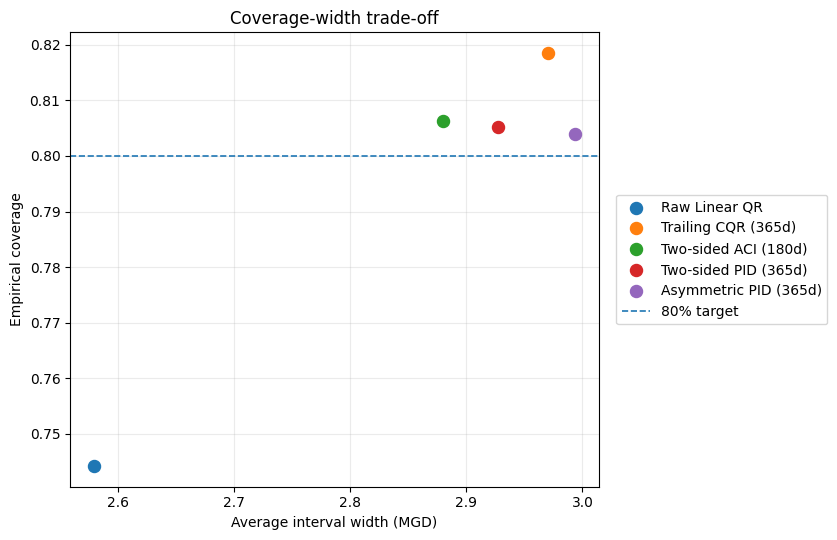

In [13]:
fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

label_map = {
    "Raw Linear QR": "Raw Linear QR",
    "Trailing CQR (365d)": "Trailing CQR (365d)",
    "Two-sided ACI (180d)": "Two-sided ACI (180d)",
    "Two-sided PID (365d)": "Two-sided PID (365d)",
    "Asymmetric PID (365d)": "Asymmetric PID (365d)",
}

for row in evaluation_summary.itertuples(
    index=False
):
    ax.scatter(
        row.average_width,
        row.coverage_80,
        s=75,
        label=label_map.get(
            row.method,
            row.method,
        ),
    )

ax.axhline(
    TARGET_COVERAGE,
    linestyle="--",
    linewidth=1.2,
    label="80% target",
)

ax.set_title(
    "Coverage-width trade-off"
)
ax.set_xlabel(
    "Average interval width (MGD)"
)
ax.set_ylabel(
    "Empirical coverage"
)
ax.grid(alpha=0.25)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)

fig.tight_layout()
plt.show()

The coverage-width view makes the trade-off especially clear. Raw QR is the narrowest
method but undercovers substantially. Once calibration is introduced, ACI lies closest
to the lower-left corner of the calibrated methods: it reaches approximately nominal
coverage with the smallest average width.

## 5. Does calibration remain stable through time?

A pooled coverage rate near 80% can hide long stretches of undercoverage followed by
overcoverage.

For an issued interval $C_t=[L_t,U_t]$, define the 90-day trailing empirical
coverage as

$$
\widehat C_t^{(90)}
=
\frac{1}{90}
\sum_{j=t-89}^{t}
\mathbf{1}\{L_j \leq y_j \leq U_j\}.
$$

This is simply the fraction of the most recent 90 issued intervals that contained the
observed demand. The corresponding `rolling_coverage_mae` reported in the tables is
the mean absolute deviation of this trajectory from the nominal target,

$$
\operatorname{MAE}_{\mathrm{coverage}}
=
\frac{1}{T}
\sum_t
\left|
\widehat C_t^{(90)}-0.80
\right|.
$$

The diagnostic therefore asks a more operational question than pooled coverage:

> **If we look at roughly the most recent quarter of forecasts, is the interval still
> behaving approximately like an 80% interval?**

This is a descriptive stability diagnostic rather than a separate finite-sample
coverage guarantee.

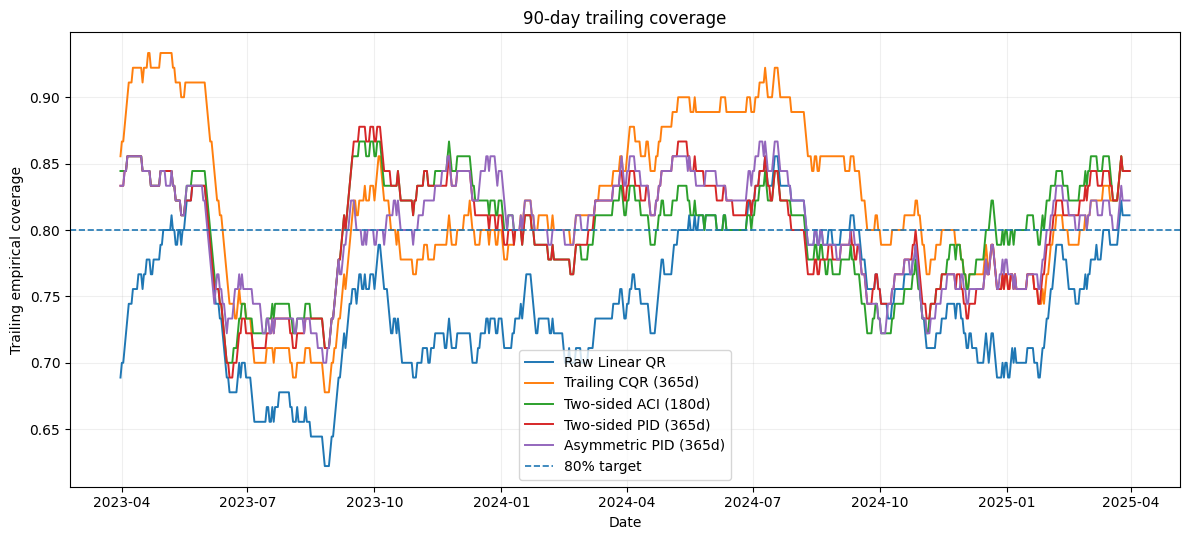

In [14]:
fig, ax = plt.subplots(
    figsize=(12, 5.5)
)

for method, frame in method_frames.items():
    covered = (
        (frame["y_true"] >= frame["lower"])
        & (frame["y_true"] <= frame["upper"])
    ).astype(float)

    rolling = (
        covered
        .rolling(
            LOCAL_COVERAGE_WINDOW,
            min_periods=LOCAL_COVERAGE_WINDOW,
        )
        .mean()
    )

    ax.plot(
        frame["date"],
        rolling,
        linewidth=1.4,
        label=method,
    )

ax.axhline(
    TARGET_COVERAGE,
    linestyle="--",
    linewidth=1.2,
    label="80% target",
)

ax.set_title(
    "90-day trailing coverage"
)
ax.set_xlabel("Date")
ax.set_ylabel(
    "Trailing empirical coverage"
)
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
plt.show()

### Adaptive calibration is more stable than the raw or trailing-score intervals

The rolling diagnostic reveals behavior that is hidden by pooled coverage.

Raw Linear QR remains below the 80% target for extended periods, including pronounced
undercoverage during the middle of 2023 and again around the beginning of 2025.

Trailing CQR corrects the pooled undercoverage, but its local coverage frequently
overshoots the target. In several periods its 90-day coverage exceeds 90%, consistent
with its relatively conservative pooled interval.

The adaptive methods remain closer to the target overall. Two-sided ACI has a
90-day coverage MAE of about **0.033**, compared with **0.049** for Trailing CQR
and **0.060** for the raw QR band. Two-sided and asymmetric PID behave similarly,
but do not provide a clear stability advantage relative to ACI.

No method eliminates temporal variation completely. All of the calibrated intervals
still experience periods of under- and overcoverage, suggesting that changes in the
underlying demand regime remain an important source of forecasting difficulty.

## 6. Seasonal and fold-level stress tests

Notebook 03 showed that the raw QR band behaved differently across seasons, with summer
providing the clearest stress test.

We therefore summarize calibration by season and retain the same nine quarterly
validation folds.

These diagnostics are not used for hyperparameter selection. They help explain where a
method's pooled performance comes from.

In [15]:
def season_from_month(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Fall"


season_order = (
    "Winter",
    "Spring",
    "Summer",
    "Fall",
)

season_rows = []
fold_rows = []

for method, frame in method_frames.items():
    temp = frame.copy()
    temp["season"] = (
        temp["date"]
        .dt.month
        .map(season_from_month)
    )

    for season in season_order:
        season_df = temp.loc[
            temp["season"] == season
        ]

        season_rows.append(
            {
                "method": method,
                "season": season,
                "n_observations": len(season_df),
                **interval_diagnostics(
                    season_df
                ),
            }
        )

    for fold, fold_df in temp.groupby(
        "evaluation_fold"
    ):
        if pd.isna(fold):
            continue

        fold_rows.append(
            {
                "method": method,
                "fold": int(fold),
                "validation_start": fold_df["date"].min(),
                "validation_end": fold_df["date"].max(),
                **interval_diagnostics(
                    fold_df
                ),
            }
        )


season_summary = pd.DataFrame(
    season_rows
)

fold_summary = pd.DataFrame(
    fold_rows
)

summer_summary = (
    season_summary.loc[
        season_summary["season"] == "Summer"
    ]
    .sort_values(
        "coverage_80",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Summer stress test:")
display(
    summer_summary.round(5)
)

print("Fold-level comparison:")
display(
    fold_summary.round(5)
)

Summer stress test:


,method,season,n_observations,coverage_80,average_width,median_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,Trailing CQR (365d),Summer,184,0.77174,4.50749,4.62952,0.18478,0.04348,0.0
1,Asymmetric PID (365d),Summer,184,0.75000,4.67058,4.62307,0.15217,0.09783,0.0
2,Two-sided PID (365d),Summer,184,0.75000,4.59399,4.55003,0.19022,0.05978,0.0
3,Two-sided ACI (180d),Summer,184,0.74457,4.52286,4.45778,0.18478,0.07065,0.0
4,Raw Linear QR,Summer,184,0.71196,4.11369,4.24748,0.21739,0.07065,0.0


Fold-level comparison:


,method,fold,validation_start,validation_end,coverage_80,average_width,median_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,Raw Linear QR,1,2023-01-01,2023-03-31,0.68889,1.47170,1.45394,0.16667,0.14444,0.0
1,Raw Linear QR,2,2023-04-01,2023-06-30,0.69231,3.02360,2.54075,0.26374,0.04396,0.0
2,Raw Linear QR,3,2023-07-01,2023-09-30,0.77174,4.01957,3.89765,0.15217,0.07609,0.0
3,Raw Linear QR,4,2023-10-01,2023-12-31,0.72826,1.58298,1.45031,0.13043,0.14130,0.0
4,Raw Linear QR,5,2024-01-01,2024-03-31,0.73626,1.65212,1.55863,0.12088,0.14286,0.0
5,Raw Linear QR,6,2024-04-01,2024-06-30,0.81319,3.78192,3.54747,0.07692,0.10989,0.0
6,Raw Linear QR,7,2024-07-01,2024-09-30,0.76087,3.92190,3.92778,0.11957,0.11957,0.0
7,Raw Linear QR,8,2024-10-01,2024-12-31,0.69565,1.90868,1.71196,0.14130,0.16304,0.0
8,Raw Linear QR,9,2025-01-01,2025-03-31,0.81111,1.82279,1.72995,0.07778,0.11111,0.0
9,Trailing CQR (365d),1,2023-01-01,2023-03-31,0.85556,2.03911,2.06184,0.07778,0.06667,0.0


### Summer remains the main calibration stress test

Calibration improves the uncertainty forecasts overall, but it does not eliminate the
seasonal difficulty identified in Notebook 3.

During summer, the raw Linear QR interval covers only about 71.2% of observations.
Every calibration method improves or modifies that behavior, but none reaches the nominal
80% target. Two-sided ACI reaches about 74.5% summer coverage with an average
width of 4.52 MGD.

The miss direction remains asymmetric. For ACI, roughly 18.5% of summer
observations fall below the calibrated lower endpoint, compared with about 7.1%
above the upper endpoint. Asymmetric PID reduces this imbalance, but does so with a
wider summer interval and still reaches only about 75% coverage.

The quarterly results show the same underlying issue. Calibration usually improves the
raw QR interval, but coverage still changes meaningfully across validation periods. For
example, ACI covers about 73.6% of Fold 2 observations and then about 87.0%
in Fold 3.

This indicates that the remaining uncertainty problem is not simply a fixed global
coverage offset. Changes in demand regime can alter both the amount and direction of
forecast error, particularly during the transition into high-demand summer periods.

## 7. Computational diagnostic

The calibration algorithms are inexpensive compared with fitting the underlying QR models,
but additional state and controller logic should still earn their place.

We record wall-clock calibration time and an approximate scalar-state count.

The state count is only a transparent bookkeeping comparison:

- Trailing CQR: \(W\) stored scores;
- ACI: \(W+1\);
- two-sided PID: \(W+2\);
- asymmetric PID: \(2W+3\).

It is not intended as a hardware-level memory benchmark.

In [16]:
runtime_rows = []

# Re-run only the calibration layer for a simple wall-clock comparison.
for method in (
    "Trailing CQR",
    "Two-sided ACI",
    "Two-sided PID",
    "Asymmetric PID",
):
    selected = selected_2022.loc[
        selected_2022["method"] == method
    ].iloc[0]

    window = int(
        selected["window"]
    )

    burn_two = burn_two_all[-window:]
    burn_low = burn_low_all[-window:]
    burn_up = burn_up_all[-window:]

    start = perf_counter()

    if method == "Trailing CQR":
        _ = run_trailing_cqr(
            online_frame,
            burn_two,
            window,
        )
        approx_state = window

    elif method == "Two-sided ACI":
        _ = run_aci(
            online_frame,
            burn_two,
            window,
            float(selected["gamma"]),
        )
        approx_state = window + 1

    elif method == "Two-sided PID":
        _ = run_pid_two_sided(
            online_frame,
            burn_two,
            window,
            float(selected["c_sat"]),
            float(selected["k_i_lower"]),
        )
        approx_state = window + 2

    else:
        _ = run_pid_asymmetric(
            online_frame,
            burn_low,
            burn_up,
            window,
            float(selected["c_sat"]),
            float(selected["k_i_lower"]),
            float(selected["k_i_upper"]),
        )
        approx_state = 2 * window + 3

    runtime = (
        perf_counter() - start
    )

    runtime_rows.append(
        {
            "method": method,
            "selected_window": window,
            "calibration_runtime_seconds": runtime,
            "approx_scalar_state": approx_state,
        }
    )

runtime_summary = pd.DataFrame(
    runtime_rows
)

display(
    runtime_summary.round(5)
)

,method,selected_window,calibration_runtime_seconds,approx_scalar_state
0,Trailing CQR,365,0.10972,365
1,Two-sided ACI,180,0.09687,181
2,Two-sided PID,365,0.10586,367
3,Asymmetric PID,365,0.19788,733


### Calibration overhead is negligible at this scale

All four calibration procedures are inexpensive relative to fitting the underlying
quantile-regression models.

The selected methods require only fractions of a second for the complete sequential
calibration pass. Two-sided ACI stores approximately 181 scalar values for its
180-day score history and adaptive state, compared with roughly 367 for two-sided
PID and 733 for asymmetric PID under their selected 365-day histories.

The absolute differences are too small to make runtime the primary model-selection
criterion here. They do, however, reinforce the appeal of ACI: its statistical
performance is competitive with the PID variants while requiring less calibration state
and a simpler update rule.

## 8. Preferred calibration method

Taken together, the results favor **two-sided Adaptive Conformal Inference with a
180-day conformity-score history** as the calibration method for this analysis.

The choice is based on the combined trade-off rather than any single metric:

- the raw Linear QR band covers only about **74.4%** of evaluation observations;
- ACI raises coverage to about **80.6%**;
- its average interval width is about **2.88 MGD**, the narrowest among the calibrated
  methods considered here;
- lower- and upper-tail miss rates remain close to the desired 10% levels;
- its 90-day local coverage is substantially more stable than the raw QR and trailing-CQR
  alternatives;
- and its update rule and calibration state remain simpler than the PID variants.

The more flexible PID constructions provide useful evidence that lower- and upper-tail
forecast errors can evolve differently, but that additional flexibility does not improve
the overall coverage-width-stability trade-off enough to displace ACI.

The final probabilistic forecasting system used in this analysis is therefore

$$
\boxed{\text{Matrix B predictors}}
\rightarrow
\boxed{\text{Linear QR at }0.10,\ 0.50,\ 0.90}
\rightarrow
\boxed{\text{two-sided ACI with a 180-day score history}}
\rightarrow
\boxed{\text{calibrated one-day-ahead uncertainty interval}}.
$$

One limitation remains important: summer coverage is still below the nominal target.
The calibrated intervals should therefore be interpreted as a substantial improvement in
sequential uncertainty calibration rather than evidence that all seasonal forecast
uncertainty has been resolved.

Finally, the 2023--2025 period is used to compare the candidate calibration methods.
ACI should therefore be described as the **preferred method for this analysis**, not as
the winner of a separate untouched final test set.

## 9. Save results

The outputs below support the public narrative and later README updates. Nothing is
committed or pushed automatically.

In [18]:
OUTPUT_DIR = (
    repo_root
    / "reports"
    / "probabilistic"
    / "calibration"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

best_within_window.to_csv(
    OUTPUT_DIR
    / "calibration_tuning_by_window.csv",
    index=False,
)

selected_2022.to_csv(
    OUTPUT_DIR
    / "calibration_selected_2022.csv",
    index=False,
)

evaluation_summary.to_csv(
    OUTPUT_DIR
    / "calibration_method_comparison.csv",
    index=False,
)

season_summary.to_csv(
    OUTPUT_DIR
    / "calibration_by_season.csv",
    index=False,
)

fold_summary.to_csv(
    OUTPUT_DIR
    / "calibration_by_fold.csv",
    index=False,
)

runtime_summary.to_csv(
    OUTPUT_DIR
    / "calibration_runtime_summary.csv",
    index=False,
)

for method, frame in method_frames.items():
    safe_name = (
        method.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )

    frame.to_csv(
        OUTPUT_DIR
        / f"{safe_name}_intervals.csv",
        index=False,
    )

print(
    "Saved calibration results to:",
    OUTPUT_DIR,
)

Saved calibration results to: /content/municipal-water-demand-forecasting/reports/probabilistic/calibration


In [19]:
from pathlib import Path

CALIBRATION_DIR = (
    repo_root
    / "reports"
    / "probabilistic"
    / "calibration"
)

expected_files = [
    "calibration_tuning_by_window.csv",
    "calibration_selected_2022.csv",
    "calibration_method_comparison.csv",
    "calibration_by_season.csv",
    "calibration_by_fold.csv",
    "calibration_runtime_summary.csv",
    "raw_linear_qr_intervals.csv",
    "trailing_cqr_365d_intervals.csv",
    "two_sided_aci_180d_intervals.csv",
    "two_sided_pid_365d_intervals.csv",
    "asymmetric_pid_365d_intervals.csv",
]

for name in expected_files:
    path = CALIBRATION_DIR / name
    status = "✓" if path.exists() else "MISSING"
    print(f"{status:8} {path.relative_to(repo_root)}")

✓        reports/probabilistic/calibration/calibration_tuning_by_window.csv
✓        reports/probabilistic/calibration/calibration_selected_2022.csv
✓        reports/probabilistic/calibration/calibration_method_comparison.csv
✓        reports/probabilistic/calibration/calibration_by_season.csv
✓        reports/probabilistic/calibration/calibration_by_fold.csv
✓        reports/probabilistic/calibration/calibration_runtime_summary.csv
✓        reports/probabilistic/calibration/raw_linear_qr_intervals.csv
✓        reports/probabilistic/calibration/trailing_cqr_365d_intervals.csv
✓        reports/probabilistic/calibration/two_sided_aci_180d_intervals.csv
✓        reports/probabilistic/calibration/two_sided_pid_365d_intervals.csv
✓        reports/probabilistic/calibration/asymmetric_pid_365d_intervals.csv


In [20]:
import subprocess

def git(*args):
    result = subprocess.run(
        ["git", *args],
        cwd=repo_root,
        text=True,
        capture_output=True,
        check=True,
    )
    return result.stdout.strip()

print(git("status", "--short"))

?? reports/probabilistic/


In [21]:
subprocess.run(
    [
        "git",
        "add",
        "reports/probabilistic/calibration/",
    ],
    cwd=repo_root,
    check=True,
)

print(git("status", "--short"))

A  reports/probabilistic/calibration/asymmetric_pid_365d_intervals.csv
A  reports/probabilistic/calibration/calibration_by_fold.csv
A  reports/probabilistic/calibration/calibration_by_season.csv
A  reports/probabilistic/calibration/calibration_method_comparison.csv
A  reports/probabilistic/calibration/calibration_runtime_summary.csv
A  reports/probabilistic/calibration/calibration_selected_2022.csv
A  reports/probabilistic/calibration/calibration_tuning_by_window.csv
A  reports/probabilistic/calibration/raw_linear_qr_intervals.csv
A  reports/probabilistic/calibration/trailing_cqr_365d_intervals.csv
A  reports/probabilistic/calibration/two_sided_aci_180d_intervals.csv
A  reports/probabilistic/calibration/two_sided_pid_365d_intervals.csv


In [27]:
# Read the token from Colab Secrets.
github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise RuntimeError(
        "GITHUB_TOKEN was not found in Colab Secrets."
    )

# Temporary credential helper for this push only.
askpass_path = Path("/tmp/git_askpass.py")

askpass_path.write_text(
    """#!/usr/bin/env python3
import os
import sys

prompt = sys.argv[1] if len(sys.argv) > 1 else ""

if "Username" in prompt:
    print("fureyc")
else:
    print(os.environ["GITHUB_TOKEN"])
"""
)

askpass_path.chmod(
    askpass_path.stat().st_mode | stat.S_IEXEC
)

env = os.environ.copy()
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = str(askpass_path)
env["GIT_TERMINAL_PROMPT"] = "0"

result = subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=repo_root,
    text=True,
    capture_output=True,
    env=env,
)

print("Return code:", result.returncode)

print("\nSTDOUT:")
print(result.stdout or "(none)")

print("\nSTDERR:")
print(result.stderr or "(none)")

if result.returncode != 0:
    raise RuntimeError(
        "Git push failed. See STDERR above."
    )

Return code: 0

STDOUT:
(none)

STDERR:
To https://github.com/fureyc/municipal-water-demand-forecasting.git
   c7351df..a50a365  main -> main



In [28]:
print("Working tree:")
print(git("status", "--short") or "(clean)")

print("\nMost recent commit:")
print(git("log", "-1", "--oneline"))

Working tree:
(clean)

Most recent commit:
a50a365 Add probabilistic calibration results
